[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/notebooks/01_Descriptive_Research/HMM_Macro_Regime_Analysis.ipynb)


# **Equity-Bond Index Correlation: Macroeconomic Regime Detection and Financial Characterization over the 1970-2025 Period**

This code is pure description (full in-sample). It initializes an HMM and fits it on a set of selected macroeconomic variables (industrial production, inflation, capacity utilization, unemployment, consumer sentiment, short-term rates and hours worked) from 1970 to 2025, in order to identify 4 distinct macroeconomic regimes. The regimes are then characterized on financial data (S&P500, T-Bond 10y, AAA, BAA) via a `RegimeStatisticalAnalyzer`-type object, which displays the means, volatilities and inter-asset correlations conditional on each regime. In addition, statistical tests between regimes are applied (Levene for volatilities and Fisher-z for correlations), complemented by 95% bootstrap confidence intervals.

The approach differs from a classical financial HMM in two ways:
- The **detection signal** is macroeconomic — the model learns regimes from the real dynamics of the economy, not from asset prices
- The **financial characterization** is performed a posteriori — return and correlation statistics are computed conditional on the regimes detected on the macro side, which makes their meaning interpretable for an investor






# GitHub connection

In [10]:
import os
import sys
import shutil

if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 1. Remove existing repo
    if os.path.exists(f'/content/{repo_name}'):
        shutil.rmtree(f'/content/{repo_name}')
        print(f"🗑️ Old repo removed")

    # 2. Purge Python cache
    for mod in list(sys.modules.keys()):
        if 'RegimeDetector' in mod:
            del sys.modules[mod]

    # 3. Clean clone
    os.chdir('/content')
    !git clone {repo_url}

    # 4. Move + add to path
    os.chdir(f'/content/{repo_name}')
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    print(f"✅ Current directory: {os.getcwd()}")

🗑️ Old repo removed
Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 979, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 979 (delta 153), reused 73 (delta 73), pack-reused 751 (from 2)
Receiving objects: 100% (979/979), 21.33 MiB | 21.82 MiB/s, done.
Resolving deltas: 100% (468/468), done.
✅ Current directory: /content/CorrelationEquityBond


# Install the ssm library from the git repo

In [2]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-6dzjtcmk
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-6dzjtcmk
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614352 sha256=46513ec493d26dce3c0cc53785083def9e4b8561c3745901e9a7e2c4a9c881aa
  Stored in directory: /tmp/pip-ephem-wheel-cache-trzz1z2e/wheels/a8/a9/68/b62b9b4d4ee3afda66bd9eec0cb2fbc9a79a7504e9d6d17397
Successfully built ssm


# Data preparation

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Financial log-return columns (already computed in the dataset)
ASSET_LOG_RET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
asset_names = ["S&P500", "T-bond 10y"]

# --- Rest unchanged ---
MACRO_SELECTED = ["INDPRO", "PPIACO", "TCU", "UNRATE", "UMCSENT", "TB3MS","CPI"]
MACRO_DIFF  = ["INDPRO", "PPIACO", "TCU", "UNRATE","CPI"]
MACRO_LEVEL = ["UMCSENT", "TB3MS"]

all_cols = ASSET_LOG_RET_VARS + MACRO_SELECTED
df_model = df[all_cols].dropna().copy()

df_model_aligned = df_model.copy()
for col in MACRO_DIFF:
    if col in df_model_aligned.columns:
        df_model_aligned[col] = df_model_aligned[col].pct_change(12)

df_model_aligned = df_model_aligned.dropna()

dates = df_model_aligned.index
train_mask = (dates <= pd.Timestamp("2025-01-01")) & (dates >= pd.Timestamp("1970-01-01"))
dates_train = dates[train_mask]

# Financial log returns for downstream analyses (checker, reporter)
Y_train_raw = df_model_aligned[ASSET_LOG_RET_VARS].values[train_mask].astype(float)

# Macro observations for the HMM fit — unchanged
X_train_raw = df_model_aligned[MACRO_SELECTED].values[train_mask].astype(float)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
data_to_fit = [X_train_scaled]

T, D_macro = X_train_scaled.shape
SEED = 120
np.random.seed(SEED)

print(f"Train: {dates_train[0].date()} → {dates_train[-1].date()} ({T} months)")
print(f"Y_train_raw shape    : {Y_train_raw.shape}")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"Variables in YoY change : {MACRO_DIFF}")
print(f"Variables in level      : {MACRO_LEVEL}")

Train: 1970-02-01 → 2025-01-01 (597 months)
Y_train_raw shape    : (597, 2)
X_train_scaled shape : (597, 7)
Variables in YoY change : ['INDPRO', 'PPIACO', 'TCU', 'UNRATE', 'CPI']
Variables in level      : ['UMCSENT', 'TB3MS']


# Initialization and fit of the descriptive HMM

In [16]:
from src.stock_bond_correlation.models.HMMMacroRegimeDetector import HMMMacroRegimeDetector
from src.stock_bond_correlation.diagnostics.statistical_tests.HMMCoherenceChecker import HMMCoherenceChecker

In [17]:
detector = HMMMacroRegimeDetector(
    n_states=3,
    random_state=42,
    kappa=10.0,
    n_restarts=10,
    n_iter=200
)

# Fit on macro variables, with financial log returns stored for the metrics
detector.fit(observations=data_to_fit, log_returns=Y_train_raw)
states = detector.viterbi_states

# The checker receives the financial log returns, not the macro ones
checker = HMMCoherenceChecker(
    detector=detector,
    log_returns=Y_train_raw,   # ← financial data
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.03,
    sig_threshold=0.45,
    sig_max_cond_number=1e12
)

checker.report_emission_stats()
for ref_idx in range(detector.K):
    checker.report_transition_stats(ref_idx=ref_idx)
checker.final_verdict()


COMPLETE EMISSIONS DIAGNOSTIC (BOOTSTRAP & TESTS)

1. ANNUAL VOLATILITIES WITH CONFIDENCE INTERVALS:


Value  Lower_Bound  Upper_Bound
Regime Label                                       
0      S&P500      0.1807       0.1340       0.2253
       T-bond 10y  0.0760       0.0605       0.0913
1      S&P500      0.1001       0.0883       0.1119
       T-bond 10y  0.0607       0.0559       0.0651
2      S&P500      0.1405       0.1208       0.1588
       T-bond 10y  0.0944       0.0766       0.1113


2. CORRELATIONS WITH CONFIDENCE INTERVALS:


,,Value,Lower_Bound,Upper_Bound
Regime,Label,,,
0,S&P500 / T-bond 10y,-0.3457,-0.5510,-0.1343
1,S&P500 / T-bond 10y,0.0717,-0.0571,0.2028
2,S&P500 / T-bond 10y,0.3409,0.1824,0.4896



3. SEPARABILITY TESTS (ALL PAIRS):
- Volatility Significance (Levene):


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,4.6901,1.0049,0.0000,True
1,Intercept,R0 -> R1,Base_Prob,0.6880,1.2279,0.5753,False
2,Intercept,R1 -> R0,Base_Prob,1.0992,1.1547,0.3412,False
3,Intercept,R1 -> R1,Base_Prob,5.9124,1.0013,0.0000,True
4,Intercept,R2 -> R0,Base_Prob,-36.8124,0.0000,0.0000,True
5,Intercept,R2 -> R1,Base_Prob,-3.8187,0.5837,0.0000,True



2. AVERAGE DYNAMICS AND PERSISTENCE:


,Average_Duration (months),Stationary_Prob,Stay_Prob
0,37.4142,0.1939,0.9733
1,93.3568,0.6450,0.9893
2,46.5447,0.1611,0.9785



HMM COHERENCE REPORT : 83.11%
1. SEPARABILITY : 66.7% (Threshold: 45%) -> OK
2. STABILITY    : VALID
3. PERSISTENCE  : 37.4 months (min 3.0) -> OK
4. CONFIDENCE   : 98.4% (Entropy) -> SOLID
--------------------------------------------------
REGIME DYNAMICS:
   Duration   Freq
0    37.414  0.194
1    93.357  0.645
2    46.545  0.161

VERDICT: MODEL VALIDATED (Robust)


np.float64(0.8311026853336015)

### Results interpretation

**Emissions — Conditional volatilities and correlations**

The three regimes are clearly ranked. **R1** is the dominant normal regime (S&P500 ≈ 10.0 %, T-bond ≈ 6.1 %, very tight bootstrap CIs of [8.8, 11.2] % and [5.6, 6.5] %). **R0** is the equity-stress / flight-to-quality regime: equity vol nearly doubles (18.1 %) while T-bond vol stays moderate (7.6 %). **R2** captures rate tensions, identified by the highest T-bond vol (9.4 %) while equity vol stays intermediate (14.1 %). The main discriminant is the **S&P500 / T-bond 10y** correlation: **−0.35 in R0** (CI [−0.55, −0.13], *flight-to-quality*), **+0.07 in R1** (CI [−0.06, 0.20], normal decoupling), **+0.34 in R2** (CI [0.18, 0.49], bearish inflationary co-movement). The R0 CI sits entirely below zero and the R2 CI entirely above zero, while R1 straddles zero — three economically distinct correlation regimes.

**Statistical separability**

6 out of 9 tests significant after Bonferroni (**66.7 %, threshold 45 % → validated**). The pairs R0↔R1 and R1↔R2 are separable on equity volatility (Levene, p_adj < 0.001), and R1↔R2 is also separable on T-bond volatility (p_adj = 0.0005), but **R0 vs R2 is separable on no asset's volatility level** (p_adj = 1.0000 on both S&P and T-bond). However, **all three Fisher-Z tests on the S&P500 / T-bond 10y correlation are significant** (R0 vs R2: p_adj = 0.0000; R0 vs R1: p_adj = 0.0004; R1 vs R2: p_adj = 0.0181). The R0/R2 distinction therefore rests entirely on the correlation *structure*, not on the variance level — a result that justifies the choice of a multivariate model over a univariate switching on S&P vol.

**Transitions and regime dynamics**

The diagonal terms (R0→R0, R1→R1, R2→R2) are all significant at p < 0.001, with stay-probabilities of 97.3 %, 98.9 % and 97.9 % respectively: the persistence of the three regimes is identified unambiguously, and the R0 ↔ R1 axis (stress ↔ calm) carries the main flow. **Structural point worth flagging:** the **R2 → R0** transition appears numerically forbidden (coef ≈ −33 in logit with R1 as reference and ≈ −37 with R2 as reference, Std_Err = 0 in both cases); the model therefore forces the path through R1 to move from a rate/inflation regime to an equity-stress regime, which limits the representation of fast switches (e.g. 2022). The very high Std_Err on the R2→R1 and R2→R2 rows when R0 is the reference (Std_Err ≈ 24, p > 0.13) is the mirror of that boundary — it reflects the near-zero R2→R0 baseline used for normalisation, not an instability of the fit itself. The average durations and long-run frequencies are consistent with a macro-cyclical reading:

| Regime | Average duration | Long-run frequency | Stay prob. | Interpretation |
|--------|------------------|--------------------|------------|----------------|
| R0 | 37.4 months | 19.4 % | 97.3 % | Equity stress / flight-to-quality |
| R1 | 93.4 months | 64.5 % | 98.9 % | Dominant normal regime |
| R2 | 46.5 months | 16.1 % | 97.9 % | Rate / inflation tension |

**Overall verdict**

**Coherence score: 83.1 % — model validated on all four criteria** (separability 66.7 %, numerical stability VALID, min persistence 37.4 months, Viterbi confidence 98.4 %). The economic reading of the three states is readable and non-redundant, with the R0/R2 distinction relying on the correlation structure (variance levels alone do not separate them). The main caveat remains the R2→R0 transition constrained to zero, to be flagged as a limitation when discussing post-inflation stress scenarios.

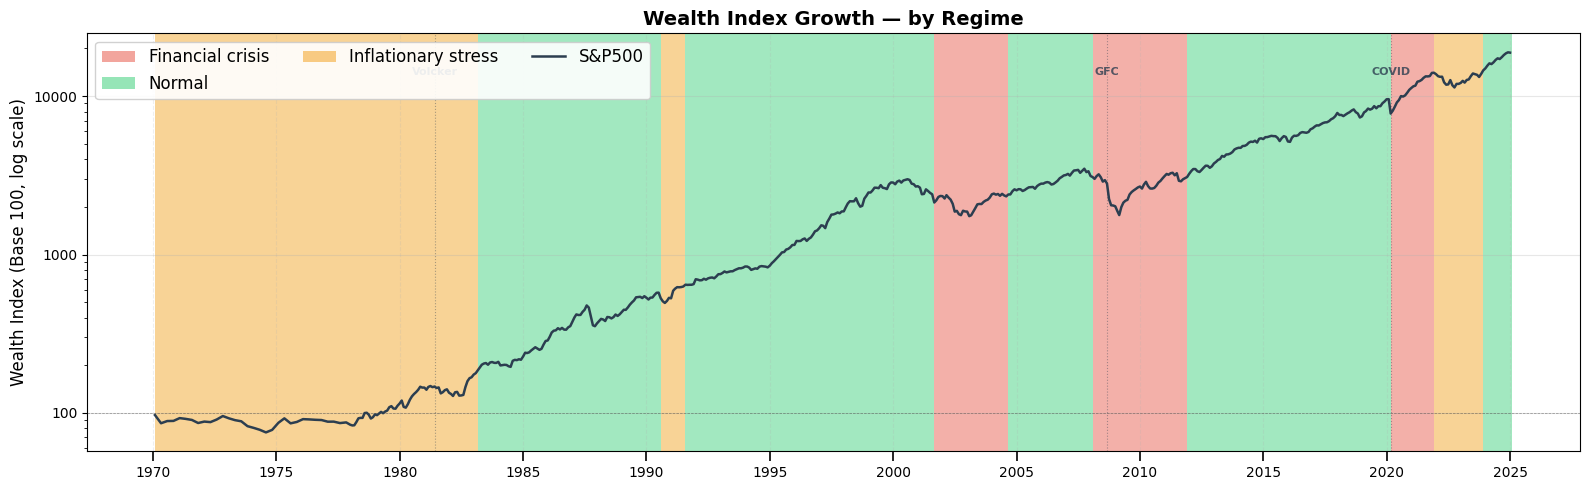

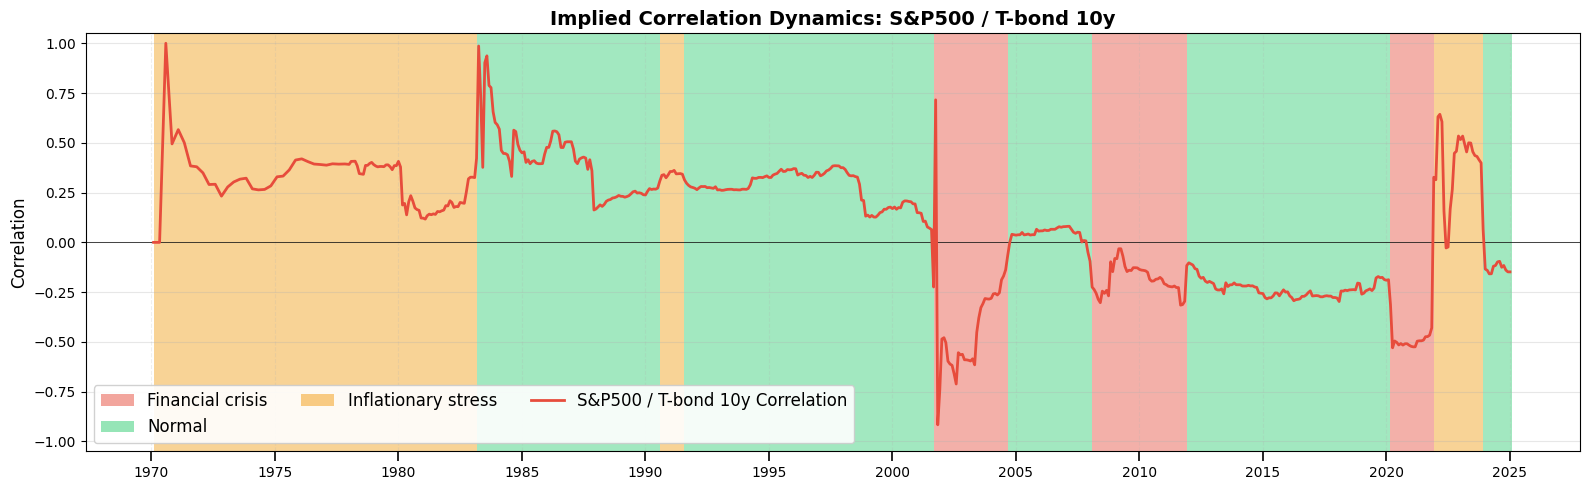

In [19]:
from src.stock_bond_correlation.visualization.RegimeReporter import RegimeReporter

regime_labels = {
    0: "Financial crisis",        # R0: flight-to-quality, credit vol ↑↑, corr S&P/T-bond < 0
    1: "Normal",                  # R1: dominant regime (65 % of the time)
    2: "Inflationary stress"      # R2: T-bond vol ↑, corr S&P/T-bond > 0
}

regime_colors = {
    0: "#e74c3c",   # red    — crisis
    1: "#2ecc71",   # green  — normal
    2: "#f39c12"    # orange — inflation / rates
}

my_crises = {"Volcker": "1981-06-01", "GFC": "2008-09-01", "COVID": "2020-03-01"}

visualizer = RegimeReporter(
    detector=detector,
    log_returns=Y_train_raw,   # ← financial data, not macro
    dates=dates_train,
    states=states,
    asset_names=asset_names,   # ["S&P500", "T-bond 10y", "Aaa", "Baa"]
    regime_labels=regime_labels,
    regime_colors=list(regime_colors.values()),
    events_dict=my_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation(asset_i=0, asset_j=1)

In [20]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful